# Notebook 2 - Abordagem multivariada técnica

Neste notebook, o experimento deixa de ser estritamente centrado no fechamento e passa a incorporar um conjunto mais rico de atributos técnicos. O objetivo é verificar se a rede melhora sua capacidade explicativa quando recebe não apenas o nível do preço, mas também sinais derivados de tendência, momentum, retorno, volatilidade e atividade de negociação.


In [ ]:
!pip install yfinance matplotlib scikit-learn torch --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
# Função com pandas puro para calcular indicadores
def add_indicators(df, col='Close', window=14):
    df[f'SMA_{window}'] = df[col].rolling(window=window).mean()
    df[f'EMA_{window}'] = df[col].ewm(span=window, adjust=False).mean()
    delta = df[col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    df[f'RSI_{window}'] = 100 - (100 / (1 + rs))
    return df

### Ampliação do espaço de atributos técnicos

A inclusão de variáveis como `SMA_14`, `EMA_14` e `RSI_14` amplia a descrição da trajetória recente dos preços, enquanto outras transformações técnicas capturam aceleração, dispersão e liquidez. Metodologicamente, esta etapa testa se a memória recorrente se beneficia de features que já sintetizam parte do comportamento de curto prazo do mercado.


In [ ]:
CSV_BK_PATH = "/content/ZAMP3_2018_2025.csv"
tickers = ['MCDC34.SA', 'MEAL3.SA', 'SBUB34.SA']

START_DATE = '2019-01-01'
END_DATE = '2025-12-02'   # exclusivo
WINDOW = 14
VOL_WINDOW = 10

dfs = []

def add_features_prefixed(df, prefix, window=14, vol_window=10):
    df = df.copy()
    df = df.sort_index()

    open_col = f'{prefix}_Open'
    high_col = f'{prefix}_High'
    low_col = f'{prefix}_Low'
    close_col = f'{prefix}_Close'
    volume_col = f'{prefix}_Volume'

    # Indicadores principais baseados no fechamento
import numpy as np

def add_features_prefixed(df, prefix, window=14, vol_window=10):
    df = df.copy()
    df = df.sort_index()

    open_col = f'{prefix}_Open'
    high_col = f'{prefix}_High'
    low_col = f'{prefix}_Low'
    close_col = f'{prefix}_Close'
    volume_col = f'{prefix}_Volume'

    df[f'{prefix}_SMA_{window}'] = df[close_col].rolling(window=window, min_periods=window).mean()
    df[f'{prefix}_EMA_{window}'] = df[close_col].ewm(span=window, adjust=False).mean()

    delta = df[close_col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    df[f'{prefix}_RSI_{window}'] = 100 - (100 / (1 + rs))

    df[f'{prefix}_Return_1d'] = df[close_col].pct_change(1)
    df[f'{prefix}_Return_5d'] = df[close_col].pct_change(5)

    df[f'{prefix}_Volatility_{vol_window}'] = df[f'{prefix}_Return_1d'].rolling(
        window=vol_window, min_periods=vol_window
    ).std()

    df[f'{prefix}_Range'] = (df[high_col] - df[low_col]) / df[close_col].replace(0, np.nan)
    df[f'{prefix}_OC_Return'] = (df[close_col] - df[open_col]) / df[open_col].replace(0, np.nan)

    df[f'{prefix}_Close_vs_SMA'] = (
        df[close_col] / df[f'{prefix}_SMA_{window}'].replace(0, np.nan) - 1
    )
    df[f'{prefix}_Close_vs_EMA'] = (
        df[close_col] / df[f'{prefix}_EMA_{window}'].replace(0, np.nan) - 1
    )

    vol_prev = df[volume_col].shift(1)
    df[f'{prefix}_Volume_Change'] = (
        (df[volume_col] - vol_prev) / vol_prev.replace(0, np.nan)
    )

    df[f'{prefix}_Volume_MA_{vol_window}'] = df[volume_col].rolling(
        window=vol_window, min_periods=vol_window
    ).mean()

    df[f'{prefix}_Volume_Relative'] = (
        df[volume_col] / df[f'{prefix}_Volume_MA_{vol_window}'].replace(0, np.nan)
    )

    df = df.replace([np.inf, -np.inf], np.nan)

    return df


# ==================================================
# ZAMP3 via CSV
# ==================================================
df_bk = pd.read_csv(CSV_BK_PATH)
df_bk['Date'] = pd.to_datetime(df_bk['Date'])
df_bk = df_bk.sort_values('Date')
df_bk = df_bk[(df_bk['Date'] >= START_DATE) & (df_bk['Date'] < END_DATE)].copy()

# caso haja duplicidade de data, mantém a última
df_bk = df_bk.drop_duplicates(subset=['Date'], keep='last')

df_bk = df_bk.set_index('Date')

# manter só colunas comuns a todos
df_bk = df_bk[['Open', 'High', 'Low', 'Close', 'Volume']].rename(columns={
    'Open': 'ZAMP3_Open',
    'High': 'ZAMP3_High',
    'Low': 'ZAMP3_Low',
    'Close': 'ZAMP3_Close',
    'Volume': 'ZAMP3_Volume'
})

df_bk = add_features_prefixed(df_bk, prefix='ZAMP3', window=WINDOW, vol_window=VOL_WINDOW)
dfs.append(df_bk)

# última data disponível da ZAMP3
data_limite = df_bk.index.max()

# ==================================================
# Outros ativos via Yahoo
# ==================================================
for t in tickers:
    df = yf.download(t, start=START_DATE, end=END_DATE, auto_adjust=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.sort_index()

    prefix = t.replace('.SA', '')

    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].rename(columns={
        'Open': f'{prefix}_Open',
        'High': f'{prefix}_High',
        'Low': f'{prefix}_Low',
        'Close': f'{prefix}_Close',
        'Volume': f'{prefix}_Volume'
    })

    df = add_features_prefixed(df, prefix=prefix, window=WINDOW, vol_window=VOL_WINDOW)
    dfs.append(df)

# ==================================================
# Consolidação final
# ==================================================
data_sem_drop = pd.concat(dfs, axis=1)

# corta tudo no fim da ZAMP3
data_sem_drop = data_sem_drop.loc[:data_limite]

data = data_sem_drop.dropna()

print("Data limite usada:", data_limite)
print("Shape sem dropna:", data_sem_drop.shape)
print("Shape com dropna:", data.shape)
print("Linhas perdidas:", len(data_sem_drop) - len(data))
print("Percentual perdido:", round((len(data_sem_drop) - len(data)) / len(data_sem_drop) * 100, 2), "%")

print("\nPeríodo final:")
print("Início:", data.index.min())
print("Fim:", data.index.max())

print("\nTotal de colunas:", len(data.columns))

data.head(2)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data limite usada: 2025-12-01 00:00:00
Shape sem dropna: (1724, 72)
Shape com dropna: (1557, 72)
Linhas perdidas: 167
Percentual perdido: 9.69 %

Período final:
Início: 2019-01-23 00:00:00
Fim: 2025-12-01 00:00:00

Total de colunas: 72


,ZAMP3_Open,ZAMP3_High,ZAMP3_Low,ZAMP3_Close,ZAMP3_Volume,ZAMP3_SMA_14,ZAMP3_EMA_14,ZAMP3_RSI_14,ZAMP3_Return_1d,ZAMP3_Return_5d,...,SBUB34_Return_1d,SBUB34_Return_5d,SBUB34_Volatility_10,SBUB34_Range,SBUB34_OC_Return,SBUB34_Close_vs_SMA,SBUB34_Close_vs_EMA,SBUB34_Volume_Change,SBUB34_Volume_MA_10,SBUB34_Volume_Relative
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-23,20.24,20.86,20.11,20.35,1225300,21.079286,20.909949,38.624339,0.000000,-0.055684,...,0.010341,0.044745,0.013868,0.0,0.0,0.042229,0.032978,-0.631579,740.0,0.945946
2019-01-24,20.18,20.78,20.18,20.70,797300,21.047143,20.881956,44.471744,0.017199,-0.039889,...,-0.006382,0.035386,0.013943,0.0,0.0,0.032726,0.022787,-0.857143,670.0,0.149254


### Normalização dos dados com `MinMaxScaler`

Como a matriz de entrada passa a reunir variáveis com naturezas e amplitudes distintas, a normalização torna-se ainda mais importante para estabilizar o processo de treinamento. Com isso, a rede passa a comparar padrões temporais entre features em uma escala compatível.


In [ ]:
# Normalizando os dados multivariados
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

In [ ]:
#Célula para ver os dados normalizados dentro da escala de 0 a 1
scaled_df = pd.DataFrame(scaled, columns=data.columns, index=data.index)
scaled_df.head(2)

,ZAMP3_Open,ZAMP3_High,ZAMP3_Low,ZAMP3_Close,ZAMP3_Volume,ZAMP3_SMA_14,ZAMP3_EMA_14,ZAMP3_RSI_14,ZAMP3_Return_1d,ZAMP3_Return_5d,...,SBUB34_Return_1d,SBUB34_Return_5d,SBUB34_Volatility_10,SBUB34_Range,SBUB34_OC_Return,SBUB34_Close_vs_SMA,SBUB34_Close_vs_EMA,SBUB34_Volume_Change,SBUB34_Volume_MA_10,SBUB34_Volume_Relative
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-23,0.837650,0.852444,0.851205,0.847261,0.026427,0.918043,0.91408,0.378742,0.550425,0.330441,...,0.443892,0.525260,0.127138,0.0,0.360571,0.553225,0.521867,0.000137,0.071252,0.098130
2019-01-24,0.834875,0.848789,0.854511,0.863510,0.017073,0.916465,0.91270,0.444673,0.587487,0.345367,...,0.401319,0.504236,0.128182,0.0,0.360571,0.526628,0.490791,0.000053,0.064492,0.015483


### Criação das sequências multivariadas

A base consolidada é convertida para o formato `[n_amostras, n_passos, n_features]`, no qual cada janela temporal contém múltiplas variáveis observadas ao longo do tempo. Essa reorganização permite que a arquitetura aprenda dependências não apenas entre instantes sucessivos, mas também entre diferentes dimensões descritivas do ativo.


In [ ]:
def create_multivariate_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0])  # prever o fechamento do primeiro ativo
    return np.array(X), np.array(y)

In [ ]:
seq_len = 60
X, y = create_multivariate_sequences(scaled, seq_len)

# Divisão treino/teste
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

### `Dataset` e `DataLoader`

A etapa de encapsulamento em `Dataset` e `DataLoader` viabiliza o treinamento em mini-lotes sem descaracterizar a estrutura sequencial das amostras. Isso contribui para a reprodutibilidade do experimento e para a separação entre engenharia de dados e otimização do modelo.


In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
train_ds = TimeSeriesDataset(X_train, y_train)
test_ds = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

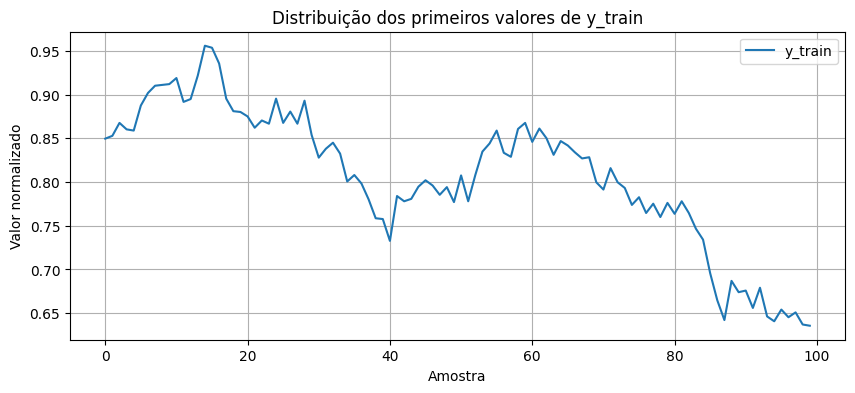

In [ ]:
# 🔍 Verificar se y_train tem variação significativa
plt.figure(figsize=(10, 4))
plt.plot(y_train[:100], label='y_train')
plt.title('Distribuição dos primeiros valores de y_train')
plt.xlabel('Amostra')
plt.ylabel('Valor normalizado')
plt.grid()
plt.legend()
plt.show()

### Definição da arquitetura LSTM-GRU

A combinação entre LSTM e GRU é mantida para investigar se uma arquitetura recorrente híbrida consegue explorar um espaço multivariado mais informativo. O interesse central aqui está em verificar se o modelo consegue integrar memória temporal e atributos técnicos em uma representação latente mais expressiva do processo de formação de preços.


In [ ]:
class LSTM_GRU_Model(nn.Module):
    def __init__(self, input_size, hidden_lstm=64, hidden_gru=32):
        super().__init__()

        # 🧠 LSTM: aprende padrões de longo prazo na série temporal
        # input_size: número de features por time step (ex: Close, RSI, EMA...)
        # hidden_lstm: número de neurônios na camada LSTM
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_lstm, batch_first=True)
        # self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)

        # 🔁 GRU: refina as representações aprendidas pela LSTM
        # Recebe como entrada a saída da LSTM
        self.gru = nn.GRU(input_size=hidden_lstm, hidden_size=hidden_gru, batch_first=True)

        # Camada densa final: transforma o hidden final da GRU em uma predição
        self.fc = nn.Linear(hidden_gru, 1)

    def forward(self, x):

        # LSTM layer
        out_lstm1, _ = self.lstm1(x)  # Shape: (batch, seq_len, hidden_lstm)
        # out_lstm2, _ = self.lstm2(x)  # Shape: (batch, seq_len, hidden_lstm)

        # GRU layer
        out_gru, _ = self.gru(out_lstm1)  # Shape: (batch, seq_len, hidden_gru)
        # out_gru, _ = self.gru(out_lstm2)  # Shape: (batch, seq_len, hidden_gru)

        # Pegamos apenas a última saída temporal
        final_output = self.fc(out_gru[:, -1, :])  # Shape: (batch, 1)

        return final_output


In [ ]:
# Detectar número de features automaticamente
input_size = X_train.shape[2]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTM_GRU_Model(input_size=X_train.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Feature Learning

Esta etapa corresponde ao aprendizado estrutural da arquitetura diante de uma entrada mais rica em informação. Antes de qualquer ajuste fino, o experimento procura validar se o modelo passa a reconhecer padrões mais complexos de dependência temporal quando recebe um conjunto técnico expandido.


## Treinamento do modelo

O comportamento das curvas de perda em treino e validação é utilizado para avaliar a estabilidade do aprendizado e possíveis sinais de subajuste ou sobreajuste. A etapa de otimização propriamente dita permanece posterior, sendo justificada apenas após a consolidação dessa capacidade estrutural de aprendizado.


Epoch  1: Train Loss = 0.028363, Val Loss = 0.000791
Epoch  2: Train Loss = 0.002297, Val Loss = 0.000264
Epoch  3: Train Loss = 0.001269, Val Loss = 0.000208
Epoch  4: Train Loss = 0.000918, Val Loss = 0.000773
Epoch  5: Train Loss = 0.000617, Val Loss = 0.000569
Epoch  6: Train Loss = 0.000446, Val Loss = 0.000928
Epoch  7: Train Loss = 0.000368, Val Loss = 0.001410
Epoch  8: Train Loss = 0.000323, Val Loss = 0.000376
Epoch  9: Train Loss = 0.000254, Val Loss = 0.000560
Epoch 10: Train Loss = 0.000304, Val Loss = 0.000643
Epoch 11: Train Loss = 0.000321, Val Loss = 0.000963
Epoch 12: Train Loss = 0.000235, Val Loss = 0.001016
Epoch 13: Train Loss = 0.000214, Val Loss = 0.000723
Epoch 14: Train Loss = 0.000205, Val Loss = 0.000509
Epoch 15: Train Loss = 0.000183, Val Loss = 0.000078
Epoch 16: Train Loss = 0.000153, Val Loss = 0.000323
Epoch 17: Train Loss = 0.000176, Val Loss = 0.000289
Epoch 18: Train Loss = 0.000184, Val Loss = 0.000436
Epoch 19: Train Loss = 0.000161, Val Loss = 0.

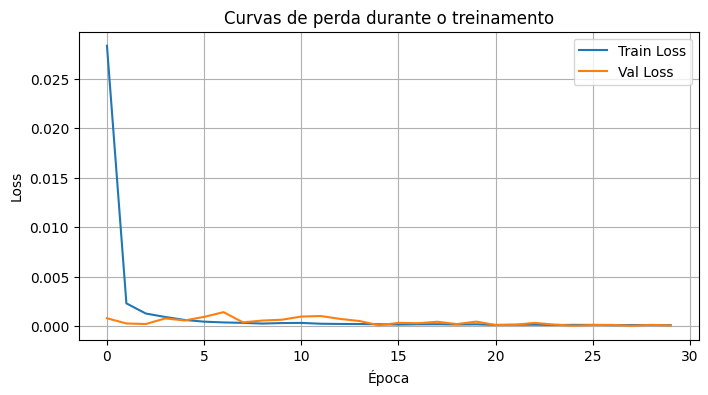

In [ ]:
# 🔁 Treinamento com validação por época + melhor modelo salvo
from copy import deepcopy
best_val_loss = float('inf')
best_model_state = None
train_losses, val_losses = [], []

for epoch in range(1, 31):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # Validação
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).squeeze()
            val_loss = criterion(preds, yb)
            val_batch_losses.append(val_loss.item())
    val_loss = np.mean(val_batch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:2d}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

    # Salvar melhor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

# Restaurar melhor modelo após o treinamento
model.load_state_dict(best_model_state)

# Plot das curvas de perda
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Curvas de perda durante o treinamento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

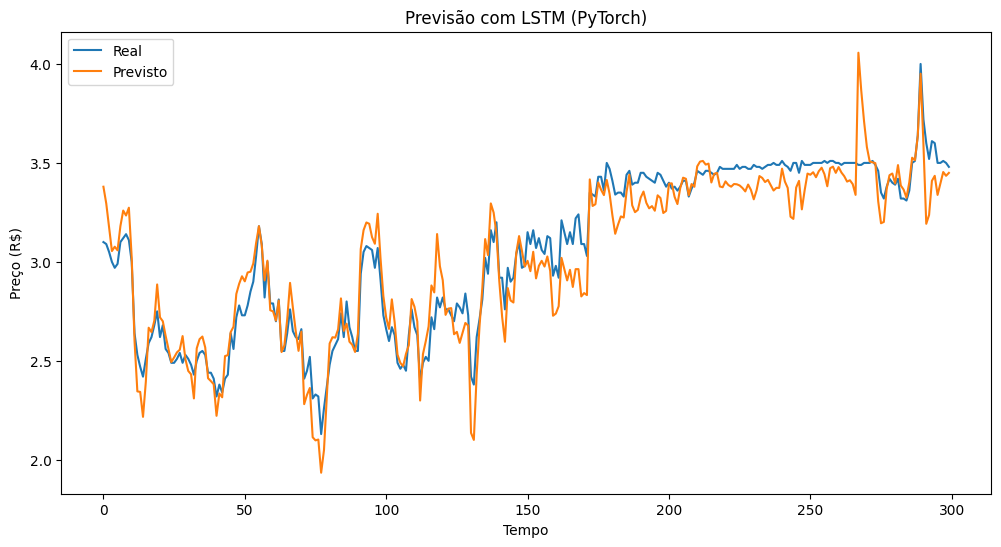

In [ ]:
# Avaliação com correção para scaler multivariado
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds.extend(out.cpu().numpy())

# Ajustar shape para inverse_transform apenas da feature alvo
preds = np.array(preds)
preds_full = np.zeros((len(preds), scaler.n_features_in_))
actual_full = np.zeros((len(y_test), scaler.n_features_in_))
preds_full[:, 0] = preds[:, 0]
actual_full[:, 0] = y_test

preds_inverse = scaler.inverse_transform(preds_full)[:, 0]
actual_inverse = scaler.inverse_transform(actual_full)[:, 0]

# Plot
plt.figure(figsize=(12,6))
plt.plot(actual_inverse, label='Real')
plt.plot(preds_inverse, label='Previsto')
plt.legend()
plt.title('Previsão com LSTM (PyTorch)')
plt.xlabel('Tempo')
plt.ylabel('Preço (R$)')
plt.show()

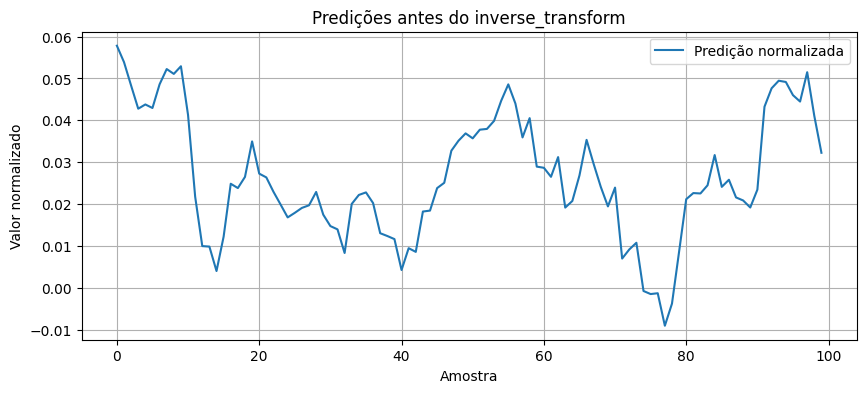

Predição (normalizada) - min: -0.0090, max: 0.0891, média: 0.0413


In [ ]:
# 🧪 Diagnóstico: distribuição das predições normalizadas
plt.figure(figsize=(10, 4))
plt.plot(preds[:100], label='Predição normalizada')
plt.title('Predições antes do inverse_transform')
plt.xlabel('Amostra')
plt.ylabel('Valor normalizado')
plt.grid()
plt.legend()
plt.show()

print(f"Predição (normalizada) - min: {preds.min():.4f}, max: {preds.max():.4f}, média: {preds.mean():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


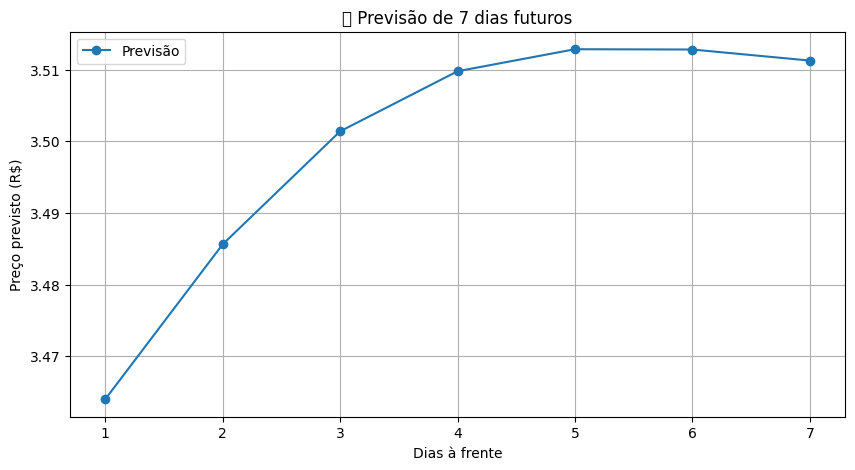

Dia +1: R$ 3.46
Dia +2: R$ 3.49
Dia +3: R$ 3.50
Dia +4: R$ 3.51
Dia +5: R$ 3.51
Dia +6: R$ 3.51
Dia +7: R$ 3.51


In [ ]:
# 🧠 Previsão de múltiplos dias à frente
model.eval()
n_future = 7  # número de dias a prever

# Última sequência disponível
last_sequence = data[-seq_len:].values
last_scaled = scaler.transform(last_sequence)
future_preds = []

# Preparar o primeiro input [1, seq_len, n_features]
current_input = torch.tensor(last_scaled, dtype=torch.float32).unsqueeze(0).to(device)

for _ in range(n_future):
    with torch.no_grad():
        next_pred = model(current_input)
        pred_val = next_pred.cpu().numpy()[0, 0]
        future_preds.append(pred_val)

    # Preparar próxima entrada
    # Manter todas as features da última linha, mas sobrescrever o target (índice 0)
    next_step = current_input[0, -1, :].cpu().numpy()
    next_step[0] = pred_val  # Substitui apenas o target
    next_step = next_step.reshape(1, -1)

    # Construir nova sequência deslocando uma posição à frente
    next_sequence = torch.cat([
        current_input[:, 1:, :],  # remove o primeiro dia
        torch.tensor(next_step, dtype=torch.float32).unsqueeze(0).to(device)  # adiciona novo dia
    ], dim=1)

    current_input = next_sequence

# Corrigir estrutura para inverse_transform
future_scaled_full = np.zeros((n_future, scaler.n_features_in_))
future_scaled_full[:, 0] = future_preds  # só preenche a coluna do target

# Inverte e extrai apenas o target original
future_prices = scaler.inverse_transform(future_scaled_full)[:, 0]

# Plot
plt.figure(figsize=(10,5))
plt.plot(range(1, n_future + 1), future_prices, marker='o', label='Previsão')
plt.title('📅 Previsão de 7 dias futuros')
plt.xlabel('Dias à frente')
plt.ylabel('Preço previsto (R$)')
plt.grid()
plt.legend()
plt.show()

# Mostrar os valores
for i, p in enumerate(future_prices):
    print(f"Dia +{i+1}: R$ {p:.2f}")

In [ ]:
# ==================================================
# CÉLULA - MÉTRICAS DE AVALIAÇÃO DO MODELO
# ==================================================
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Garantir arrays 1D
y_true = np.array(actual_inverse).reshape(-1)
y_pred = np.array(preds_inverse).reshape(-1)

# ------------------------------------------
# Métricas de regressão
# ------------------------------------------
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

# Evitar divisão por zero no MAPE
mask_mape = y_true != 0
mape = np.mean(np.abs((y_true[mask_mape] - y_pred[mask_mape]) / y_true[mask_mape])) * 100

r2 = r2_score(y_true, y_pred)

# ------------------------------------------
# Métrica direcional
# ------------------------------------------
# Compara se o modelo acertou a direção do movimento
# usando a variação entre t-1 e t
real_diff = np.diff(y_true)
pred_diff = np.diff(y_pred)

direcao_real = np.sign(real_diff)
direcao_pred = np.sign(pred_diff)

directional_accuracy = np.mean(direcao_real == direcao_pred) * 100

# ------------------------------------------
# Baseline ingênua
# ------------------------------------------
# Previsão de hoje = valor de ontem
baseline_pred = y_true[:-1]
baseline_true = y_true[1:]

baseline_mae = mean_absolute_error(baseline_true, baseline_pred)
baseline_mse = mean_squared_error(baseline_true, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)

mask_baseline_mape = baseline_true != 0
baseline_mape = np.mean(
    np.abs((baseline_true[mask_baseline_mape] - baseline_pred[mask_baseline_mape]) / baseline_true[mask_baseline_mape])
) * 100

baseline_r2 = r2_score(baseline_true, baseline_pred)

baseline_real_diff = np.diff(baseline_true)
baseline_pred_diff = np.diff(baseline_pred)

baseline_directional_accuracy = np.mean(
    np.sign(baseline_real_diff) == np.sign(baseline_pred_diff)
) * 100

# ------------------------------------------
# Tabela resumo
# ------------------------------------------
metricas = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "MAPE (%)", "R²", "Directional Accuracy (%)"],
    "LSTM": [mae, mse, rmse, mape, r2, directional_accuracy],
    "Baseline Ingênua": [
        baseline_mae,
        baseline_mse,
        baseline_rmse,
        baseline_mape,
        baseline_r2,
        baseline_directional_accuracy
    ]
})

print("=== MÉTRICAS DO MODELO ===")
display(metricas)

# ------------------------------------------
# Interpretação simples
# ------------------------------------------
print("Resumo rápido:")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.6f}")
print(f"Dir. Accuracy: {directional_accuracy:.2f}%")

=== MÉTRICAS DO MODELO ===


,Métrica,LSTM,Baseline Ingênua
0,MAE,0.098042,0.063010
1,MSE,0.015422,0.009172
2,RMSE,0.124184,0.095770
3,MAPE (%),3.263680,2.194259
4,R²,0.905513,0.943989
5,Directional Accuracy (%),66.555184,37.919463


Resumo rápido:
MAE  : 0.098042
RMSE : 0.124184
MAPE : 3.26%
R²   : 0.905513
Dir. Accuracy: 66.56%
